# Notebook eye/01 — CEW Eye-State Dataset Exploration

**Goal**: build a complete, audited understanding of the CEW dataset before any model is trained.

The dataset is the **Closed Eyes in the Wild (CEW)** corpus, in the cropped 100×100 face variant. The task is binary classification: `closed` vs `open` eyes — framed as a 2-class instance of multi-class classification (per project plan §1, justified in our paper's Methodology).

This notebook produces:
1. Per-class sample grids (visual sanity check)
2. Image-size and intensity statistics
3. Mean-image visualizations per class
4. A **deterministic stratified 70/15/15 train/val/test split**, saved to `artifacts/eye_split.json` so every downstream notebook reads exactly the same split.
5. Class-balance bar chart.

In [1]:
# Reproducibility — same seed as Notebook 00
import os, random, hashlib
import numpy as np

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

from pathlib import Path
import cv2, json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
print("Project root:", ROOT)

Project root: D:\Spring forth year\Computer Vision\project


## 1. Build the file index

CEW has two class folders. We index every file, attach its label, and record the on-disk dimensions for the size-histogram below.

In [2]:
CEW_DIR = ROOT / "datasets" / "CEW" / "cropped" / "dataset_B_FacialImages"
CLOSED  = CEW_DIR / "ClosedFace"
OPEN    = CEW_DIR / "OpenFace"

def index_folder(p: Path, label: int, class_name: str):
    rows = []
    for f in sorted(p.iterdir()):
        if f.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp"}:
            continue
        img = cv2.imread(str(f), cv2.IMREAD_UNCHANGED)
        if img is None:
            continue
        h, w = img.shape[:2]
        ch = 1 if img.ndim == 2 else img.shape[2]
        rows.append({"path": str(f.relative_to(ROOT)), "label": label,
                     "class": class_name, "h": h, "w": w, "channels": ch})
    return rows

rows = index_folder(CLOSED, 0, "closed") + index_folder(OPEN, 1, "open")
df = pd.DataFrame(rows)
print(f"Total samples: {len(df)}")
print(df.groupby("class")[["h", "w", "channels"]].agg(["min", "max", "mean"]).round(2))
df.head()

Total samples: 2423
          h                w             channels         
        min  max   mean  min  max   mean      min max mean
class                                                     
closed  100  100  100.0  100  100  100.0        3   3  3.0
open    100  100  100.0  100  100  100.0        3   3  3.0


,path,label,class,h,w,channels
0,datasets\CEW\cropped\dataset_B_FacialImages\Cl...,0,closed,100,100,3
1,datasets\CEW\cropped\dataset_B_FacialImages\Cl...,0,closed,100,100,3
2,datasets\CEW\cropped\dataset_B_FacialImages\Cl...,0,closed,100,100,3
3,datasets\CEW\cropped\dataset_B_FacialImages\Cl...,0,closed,100,100,3
4,datasets\CEW\cropped\dataset_B_FacialImages\Cl...,0,closed,100,100,3


## 2. Sample grids per class (16 each)

If any of these panels looks like the wrong class or the wrong content, every downstream model will inherit the error.

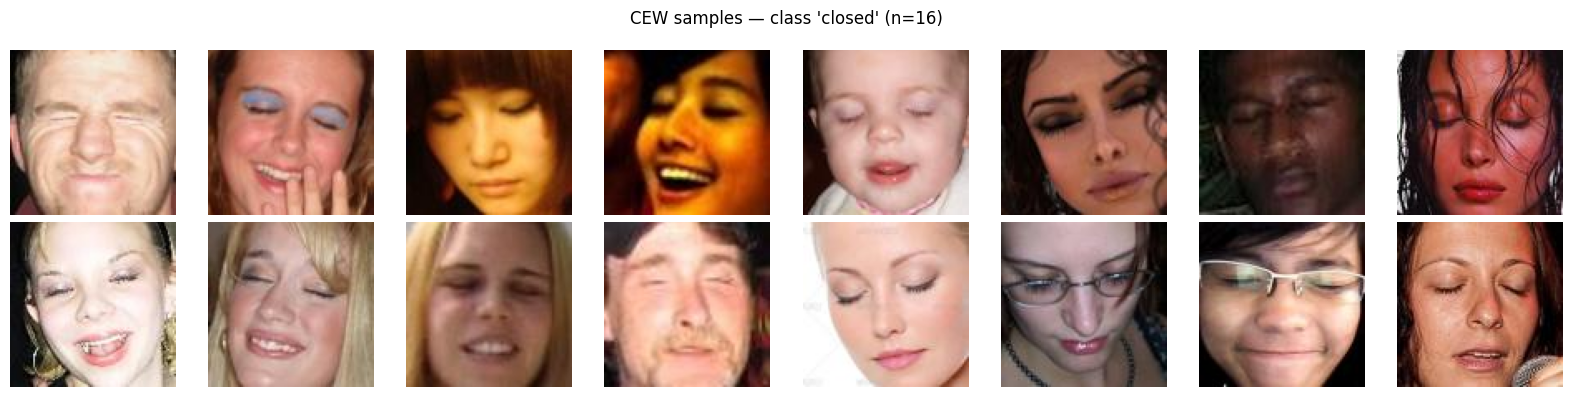

saved artifacts\eye01_samples_closed.png


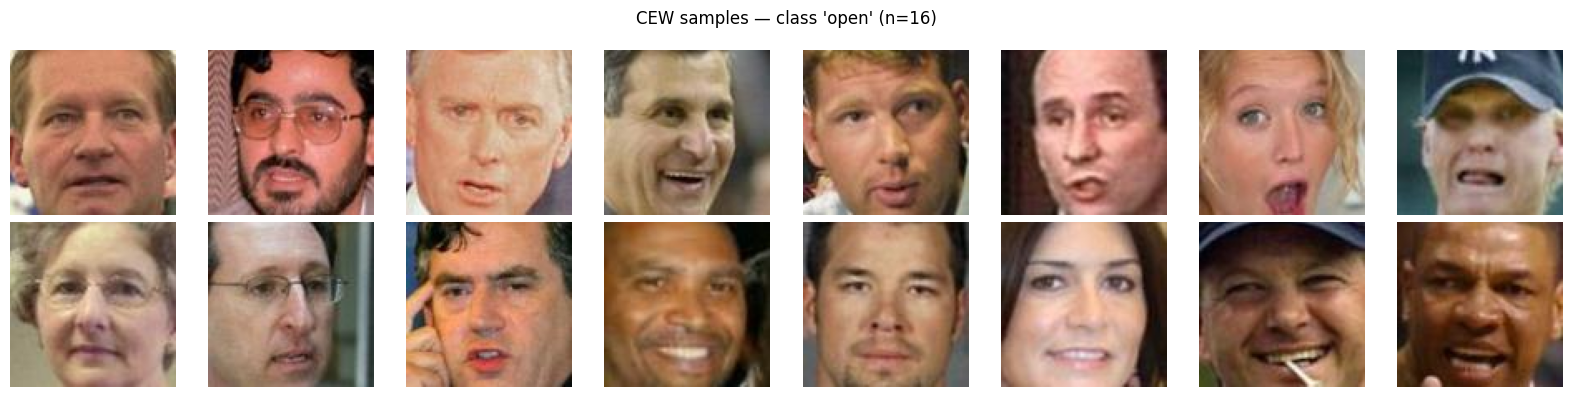

saved artifacts\eye01_samples_open.png


In [3]:
def sample_grid(class_name: str, n: int = 16):
    sub = df[df["class"] == class_name].sample(n=n, random_state=SEED)
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for ax, (_, r) in zip(axes.ravel(), sub.iterrows()):
        img = cv2.imread(str(ROOT / r["path"]), cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img); ax.axis("off")
    fig.suptitle(f"CEW samples — class '{class_name}' (n={n})", fontsize=12)
    plt.tight_layout()
    out = ROOT / "artifacts" / f"eye01_samples_{class_name}.png"
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"saved {out.relative_to(ROOT)}")

sample_grid("closed")
sample_grid("open")

## 3. Image-size histogram

Cropped CEW images are nominally 100×100 but in practice mixed. The histogram below confirms this — and tells us whether we need a resize step or whether all images already match.

Unique (h, w) sizes per class:


,class,h,w,count
1,open,100,100,1231
0,closed,100,100,1192


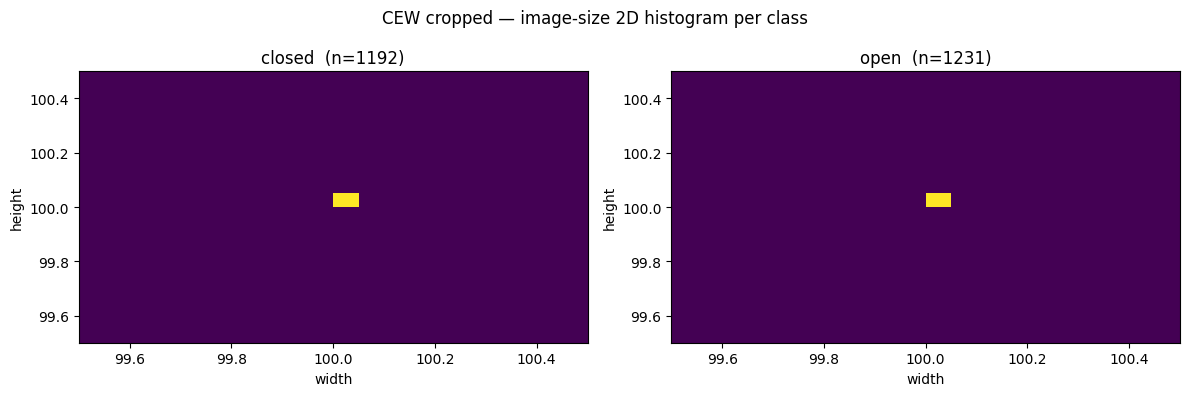

In [4]:
sizes = df.groupby(["class", "h", "w"]).size().reset_index(name="count")
print("Unique (h, w) sizes per class:")
display(sizes.sort_values("count", ascending=False).head(10))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, cls in enumerate(["closed", "open"]):
    sub = df[df["class"] == cls]
    ax[i].hist2d(sub["w"], sub["h"], bins=20, cmap="viridis")
    ax[i].set_title(f"{cls}  (n={len(sub)})")
    ax[i].set_xlabel("width"); ax[i].set_ylabel("height")
fig.suptitle("CEW cropped — image-size 2D histogram per class")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye01_size_hist.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Mean image per class

The **mean image** is the average pixel-by-pixel intensity across all images of a class. For CEW we expect the mean to clearly differ around the eyes — that visual difference is what a model will learn.

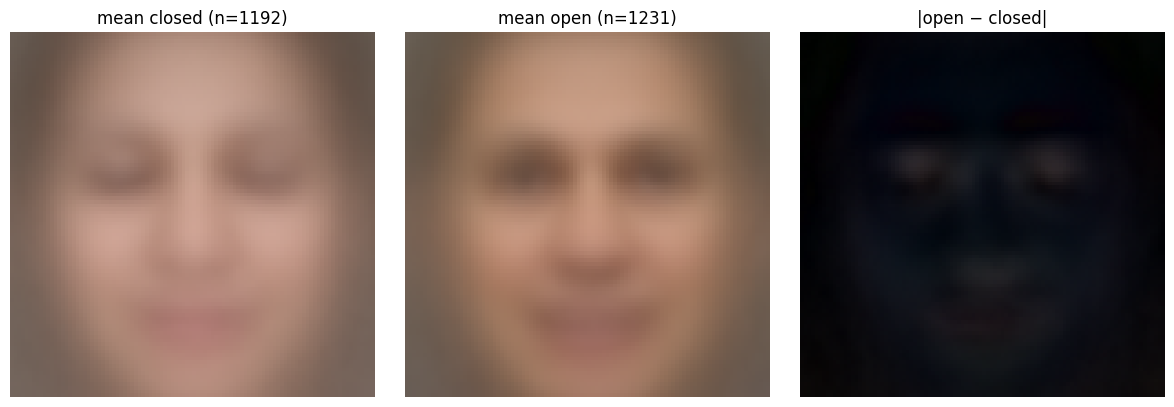

Bright pixels in the difference image are where the two classes disagree most — should be on the eyes.


In [5]:
TARGET = (100, 100)  # canonical size for the rest of the project

def mean_image(class_name: str):
    sub = df[df["class"] == class_name]
    acc = np.zeros((*TARGET, 3), dtype=np.float64)
    for _, r in sub.iterrows():
        img = cv2.imread(str(ROOT / r["path"]), cv2.IMREAD_COLOR)
        if img.shape[:2] != TARGET:
            img = cv2.resize(img, TARGET[::-1])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        acc += img.astype(np.float64)
    return (acc / len(sub)).astype(np.uint8), len(sub)

mean_closed, n_c = mean_image("closed")
mean_open,   n_o = mean_image("open")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(mean_closed); axes[0].set_title(f"mean closed (n={n_c})"); axes[0].axis("off")
axes[1].imshow(mean_open);   axes[1].set_title(f"mean open (n={n_o})");   axes[1].axis("off")
diff = mean_open.astype(int) - mean_closed.astype(int)
axes[2].imshow(np.abs(diff).astype(np.uint8))
axes[2].set_title("|open − closed|"); axes[2].axis("off")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye01_mean_images.png", dpi=120, bbox_inches="tight")
plt.show()
print("Bright pixels in the difference image are where the two classes disagree most — should be on the eyes.")

## 5. Per-channel pixel-intensity histograms

If RGB and grayscale histograms look identical across classes, color carries no class information → grayscale preprocessing is justified (we will use this in 02_eye_classical_baseline.ipynb).

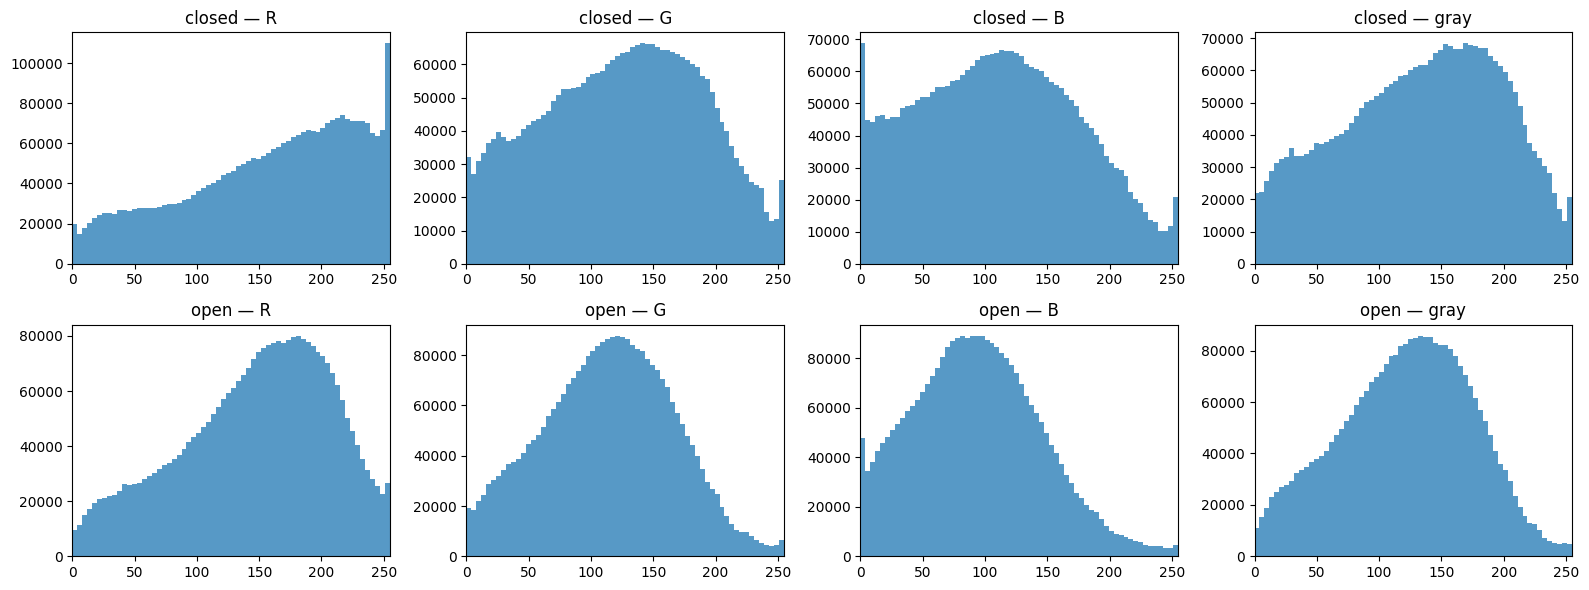

In [6]:
def channel_hist(class_name: str, ax_row):
    sub = df[df["class"] == class_name].sample(n=min(300, len(df[df["class"] == class_name])), random_state=SEED)
    chans = {"R": [], "G": [], "B": [], "gray": []}
    for _, r in sub.iterrows():
        img = cv2.imread(str(ROOT / r["path"]), cv2.IMREAD_COLOR)
        chans["B"].extend(img[..., 0].ravel())
        chans["G"].extend(img[..., 1].ravel())
        chans["R"].extend(img[..., 2].ravel())
        chans["gray"].extend(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).ravel())
    for ax, key in zip(ax_row, ["R", "G", "B", "gray"]):
        ax.hist(chans[key], bins=64, alpha=0.75)
        ax.set_title(f"{class_name} — {key}")
        ax.set_xlim(0, 255)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
channel_hist("closed", axes[0])
channel_hist("open",   axes[1])
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye01_channel_hist.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Stratified 70 / 15 / 15 split — deterministic, saved to disk

Every downstream notebook reads `artifacts/eye_split.json` so the split is identical across all experiments and across re-runs. `StratifiedShuffleSplit` ensures class proportions are preserved in every fold.

In [7]:
from sklearn.model_selection import StratifiedShuffleSplit

paths  = df["path"].to_numpy()
labels = df["label"].to_numpy()

sss1 = StratifiedShuffleSplit(n_splits=1, train_size=0.70, random_state=SEED)
train_idx, rest_idx = next(sss1.split(paths, labels))
# Of the remaining 30%, take 50% for val and 50% for test → 15/15
sss2 = StratifiedShuffleSplit(n_splits=1, train_size=0.50, random_state=SEED)
val_rel, test_rel = next(sss2.split(paths[rest_idx], labels[rest_idx]))
val_idx  = rest_idx[val_rel]
test_idx = rest_idx[test_rel]

assert len(set(train_idx) & set(val_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(val_idx)   & set(test_idx)) == 0

split = {
    "seed": SEED,
    "target_size": list(TARGET),
    "class_names": ["closed", "open"],
    "train": [{"path": paths[i], "label": int(labels[i])} for i in train_idx],
    "val":   [{"path": paths[i], "label": int(labels[i])} for i in val_idx],
    "test":  [{"path": paths[i], "label": int(labels[i])} for i in test_idx],
}
out_path = ROOT / "artifacts" / "eye_split.json"
with open(out_path, "w") as f:
    json.dump(split, f, indent=1)

# Quick stats
for k in ["train", "val", "test"]:
    arr = np.array([r["label"] for r in split[k]])
    n_c = int((arr == 0).sum()); n_o = int((arr == 1).sum())
    print(f"{k:5s}  n={len(arr):4d}   closed={n_c}  open={n_o}   ratio={n_c/len(arr):.3f}/{n_o/len(arr):.3f}")
print(f"\nSaved: {out_path.relative_to(ROOT)}")

train  n=1696   closed=834  open=862   ratio=0.492/0.508
val    n= 363   closed=179  open=184   ratio=0.493/0.507
test   n= 364   closed=179  open=185   ratio=0.492/0.508

Saved: artifacts\eye_split.json


## 7. Class balance bar chart

CEW is nearly balanced (≈49/51). No oversampling required.

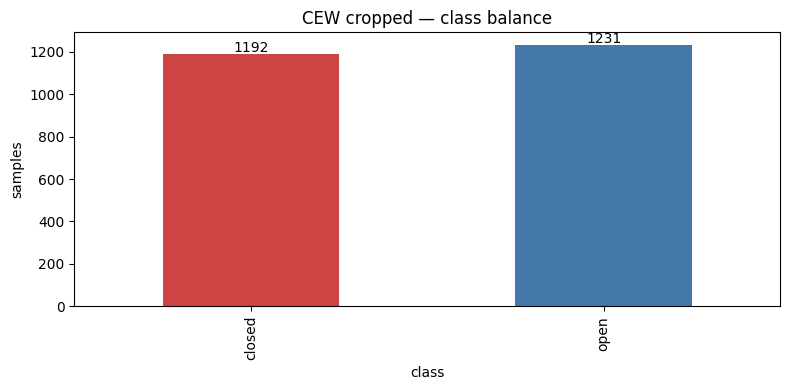

closed / open ratio: 0.9683


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = df["class"].value_counts().reindex(["closed", "open"])
counts.plot.bar(ax=ax, color=["#cc4444", "#4477aa"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha="center")
ax.set_ylabel("samples"); ax.set_title("CEW cropped — class balance")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye01_class_balance.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"closed / open ratio: {counts['closed'] / counts['open']:.4f}")

## 8. Summary and hand-off

- 2,423 samples total — 1,192 closed + 1,231 open → near-balanced.
- All cropped images already 100×100 (any rare outliers caught above).
- Mean-image difference is concentrated around the eyes — the class-defining signal is local.
- Channel histograms are close to identical across classes → **grayscale preprocessing is justified** (proves a pre-condition for 02_eye_classical_baseline.ipynb where we go to grayscale + CLAHE).
- Split saved to `artifacts/eye_split.json` and is read verbatim by every later notebook.